In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
train_df = pd.read_csv(r'C:\Users\nodos\Downloads\train_task1.csv')
test_df = pd.read_csv(r'C:\Users\nodos\Downloads\test_task1.csv')

In [32]:
test_df

,date,product_id,category_id,stock,sales,price,discount,cheques_last_sale,hours_last_sale
0,2024-08-01 13:00:00,802411,790504,2.0,1.0,49.99,0.100020,78.0,18.217500
1,2024-08-01 13:00:00,802415,700208,5.0,0.0,999.99,0.000000,46027.0,903.761960
2,2024-08-01 13:00:00,939414,700203,2.0,0.0,379.99,0.004571,39964.0,1193.562700
3,2024-08-01 13:00:00,1055225,760405,2.0,0.0,149.99,0.004444,21880.0,889.609200
4,2024-08-01 13:00:00,1049533,681107,27.0,0.0,44.99,0.003077,1053.0,23.143888
...,...,...,...,...,...,...,...,...,...
19995,2024-08-01 03:00:00,885554,801003,0.0,0.0,244.99,0.003875,190185.0,699.000000
19996,2024-08-01 03:00:00,890019,800402,0.0,0.0,134.99,0.001562,190185.0,699.000000
19997,2024-08-01 03:00:00,890472,710302,37.0,0.0,69.99,0.001250,327.0,15.084444
19998,2024-08-01 03:00:00,890168,580304,17.0,0.0,249.99,0.000000,394.0,9.051945


In [12]:
print('MIN date', test_df['date'].min())
print('MAX date', test_df['date'].max())

MIN date 2024-08-01 00:00:00
MAX date 2024-08-01 13:00:00


In [7]:
train_df

,date,product_id,category_id,stock,sales,price,discount,cheques_last_sale,hours_last_sale,target
0,2024-05-08 01:00:00,1038040,780202,0.0,0.0,69.99,0.003600,71783.0,0.000000,0
1,2024-05-08 01:00:00,545978,740602,0.0,0.0,79.99,0.000000,71783.0,0.000000,0
2,2024-05-08 01:00:00,905362,680405,13.0,0.0,129.99,0.000000,626.0,9.285277,0
3,2024-05-08 01:00:00,545626,580605,11893.0,0.0,199.99,0.000000,933.0,53.618057,0
4,2024-05-08 01:00:00,545422,810402,9.0,0.0,1099.00,0.000000,67073.0,1228.055000,0
...,...,...,...,...,...,...,...,...,...,...
10537106,2024-07-31 23:00:00,932916,680705,0.0,0.0,94.99,0.002083,190185.0,695.000000,0
10537107,2024-07-31 23:00:00,934422,790205,0.0,0.0,0.00,0.000000,36164.0,599.000000,0
10537108,2024-07-31 23:00:00,934439,700303,0.0,0.0,239.00,0.000000,190185.0,695.000000,0
10537109,2024-07-31 23:00:00,934441,710202,48.0,0.0,64.99,0.000000,919.0,223.654720,0


# Small EDA

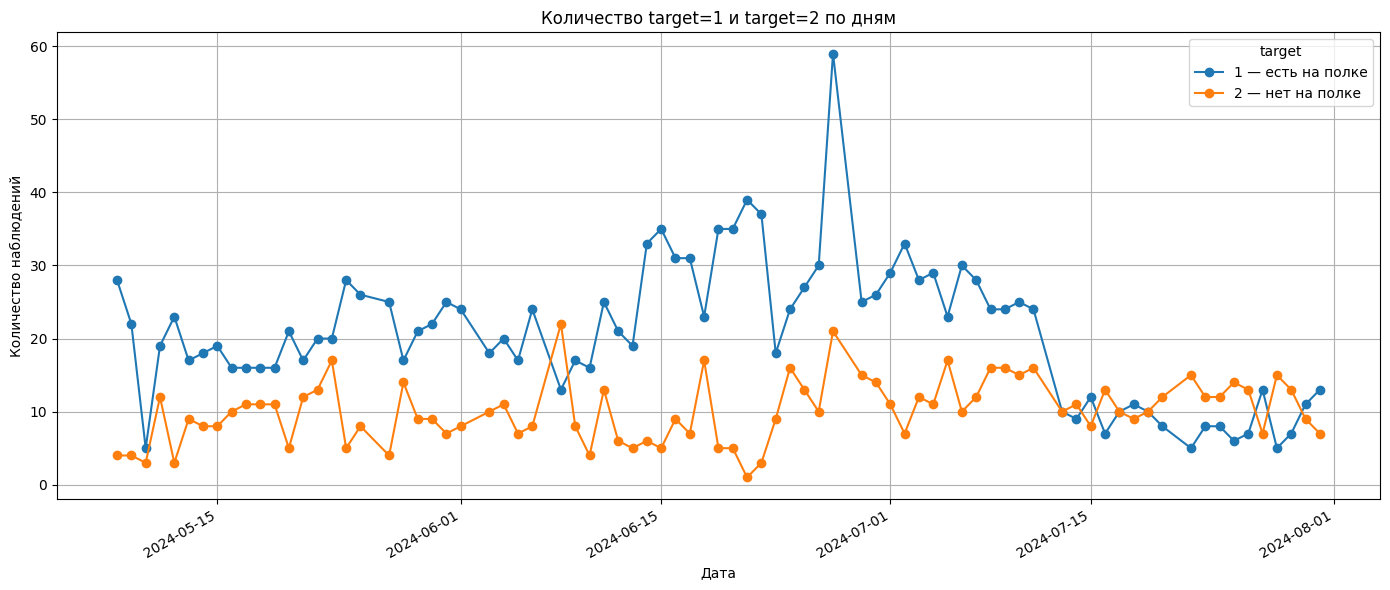

In [ ]:
# Убедимся, что дата — datetime
train_df['date'] = pd.to_datetime(train_df['date'])

# Оставим только target ∈ {1, 2}
filtered = train_df[train_df['target'].isin([1, 2])]

# Группируем по дате (день) и target
daily_counts = (
    filtered
    .groupby([pd.Grouper(key='date', freq='D'), 'target'])
    .size()
    .unstack(fill_value=0)
)

# Построим график
daily_counts.plot(figsize=(14, 6), marker='o')
plt.title('Количество target=1 и target=2 по дням')
plt.xlabel('Дата')
plt.ylabel('Количество наблюдений')
plt.grid(True)
plt.legend(title='target', labels=['1 — есть на полке', '2 — нет на полке'])
plt.tight_layout()
plt.show()


**Промежуточный вывод**  

На большинстве дат количество случаев, когда товар был на полке (target=1), значительно превышает случаи его отсутствия (target=2). Это говорит либо о достаточной эффективности системы пополнения запасов либо о возможном избытке товаров на складе (если stock высокий). Отдельные всплески (например, 2024-07-15 и 2024-08-01) могут указывать на сбои в поставках, увеличение спроса (если sales в эти дни высокие), ошибки персонала (неправильное размещение товаров)  

График не показывает четкой сезонности  

Нужно будет проверить корреляцию, балансировку, возможно, добавить временные признаки

In [21]:
# Считаем количество вхождений по product_id и target
product_target_counts = train_df.groupby(['product_id', 'target']).size().unstack(fill_value=0)

# Убедимся, что все target присутствуют
for col in [0, 1, 2]:
    if col not in product_target_counts.columns:
        product_target_counts[col] = 0

# Добавим метрику score
product_target_counts['score'] = (product_target_counts[1] + product_target_counts[2]) / (product_target_counts[0] + 1e-5)

# Переименуем колонки
product_target_counts = product_target_counts.rename(columns={
    1: 'count_target_1',
    2: 'count_target_2',
    0: 'count_target_0'
})

# Добавим category_id — возьмём первую категорию, связанную с каждым product_id
product_to_category = train_df.drop_duplicates(subset='product_id')[['product_id', 'category_id']]
product_target_counts = product_target_counts.reset_index().merge(product_to_category, on='product_id', how='left')

# Сортируем по score
product_target_counts = product_target_counts.sort_values(by='score', ascending=False)

# Финальный результат
product_target_counts.head(30)


,product_id,count_target_0,count_target_1,count_target_2,score,category_id
3856,1008275,2017,9,13,0.010907,580304
3905,1010638,2018,5,16,0.010406,710203
4181,1032783,2021,1,17,0.008906,740309
3014,921802,2023,2,14,0.007909,800208
39,377615,2024,10,5,0.007411,750304
2639,888639,2024,1,14,0.007411,710602
4214,1033717,2024,5,10,0.007411,690202
1737,750071,2025,11,3,0.006914,580402
3620,981375,2025,10,4,0.006914,860202
2393,862179,2026,6,7,0.006417,690202


In [ ]:
# Оставим только строки, где target != 0
filtered_df = train_df[train_df['target'] != 0]

# Самый частый product_id среди target ≠ 0
top_product_id = filtered_df['product_id'].value_counts().idxmax()
top_product_df = filtered_df[filtered_df['product_id'] == top_product_id]
top_product_df


,date,product_id,category_id,stock,sales,price,discount,cheques_last_sale,hours_last_sale,target
62809,2024-05-08 13:00:00,1008275,580304,206.0,0.0,599.99,0.0,8509.0,182.895000,2
187186,2024-05-09 13:00:00,1008275,580304,206.0,0.0,599.99,0.0,9690.0,206.895000,2
438764,2024-05-11 13:00:00,1008275,580304,0.0,0.0,599.99,0.0,12487.0,254.895000,2
686668,2024-05-13 13:00:00,1008275,580304,9700.0,0.0,599.99,0.0,110.0,1.327222,1
929949,2024-05-15 13:00:00,1008275,580304,2254.0,0.0,599.99,0.0,263.0,14.992500,1
1055835,2024-05-16 13:00:00,1008275,580304,450.0,0.0,499.99,0.0,1071.0,18.229723,2
1180929,2024-05-17 13:00:00,1008275,580304,450.0,0.0,499.99,0.0,1205.0,42.336388,2
1303890,2024-05-18 13:00:00,1008275,580304,15896.0,1090.0,499.99,0.0,106.0,0.323333,2
1429539,2024-05-19 13:00:00,1008275,580304,8658.0,332.0,499.99,0.1,10.0,2.510000,1
1550843,2024-05-20 13:00:00,1008275,580304,2544.0,0.0,499.99,0.0,109.0,16.032778,1


In [ ]:
# Самая частая category_id среди target ≠ 0
top_category_id = filtered_df['category_id'].value_counts().idxmax()
top_category_df = filtered_df[filtered_df['category_id'] == top_category_id]
top_category_df


,date,product_id,category_id,stock,sales,price,discount,cheques_last_sale,hours_last_sale,target
310329,2024-05-10 13:00:00,456310,690202,8.0,1.0,399.99,0.148939,128.0,71.053890,1
435477,2024-05-11 13:00:00,828942,690202,38.0,0.0,141.00,0.000000,349.0,16.813612,1
436034,2024-05-11 13:00:00,862179,690202,13.0,0.0,219.99,0.001900,909.0,39.881110,2
437295,2024-05-11 13:00:00,726099,690202,24.0,0.0,179.99,0.001800,1341.0,93.682500,1
438307,2024-05-11 13:00:00,1033714,690202,11.0,1.0,329.99,0.131582,118.0,40.154724,1
...,...,...,...,...,...,...,...,...,...,...
7749501,2024-07-09 13:00:00,726099,690202,7.0,0.0,169.99,0.002272,545.0,19.132223,1
8494062,2024-07-15 13:00:00,724401,690202,2.0,0.0,369.98,0.001778,1779.0,50.878890,1
9113201,2024-07-20 13:00:00,1057602,690202,66.0,0.0,59.99,0.000000,900.0,23.880556,1
9116752,2024-07-20 13:00:00,1033738,690202,16.0,1.0,479.99,0.200003,109.0,522.121400,1


In [24]:
# Считаем количество target по каждой категории
category_target_counts = train_df.groupby(['category_id', 'target']).size().unstack(fill_value=0)

# Убедимся, что все target есть
for col in [1, 2]:
    if col not in category_target_counts.columns:
        category_target_counts[col] = 0

# Добавляем суммарное количество (target = 1 + target = 2)
category_target_counts['target_sum'] = category_target_counts[1] + category_target_counts[2]

# Переименуем колонки для читаемости
category_target_counts = category_target_counts.rename(columns={
    1: 'count_target_1',
    2: 'count_target_2'
})

# Сортируем по target_sum и берём топ-20
top_categories = category_target_counts.sort_values(by='target_sum', ascending=False).head(20)

# Финальный результат
top_categories = top_categories[['count_target_1', 'count_target_2', 'target_sum']]
top_categories.reset_index(inplace=True)
top_categories.head(20)


target,category_id,count_target_1,count_target_2,target_sum
0,690202,83,35,118
1,850302,45,44,89
2,860202,55,19,74
3,740704,18,30,48
4,790205,27,13,40
5,740202,24,11,35
6,920203,23,12,35
7,710303,18,15,33
8,710203,13,18,31
9,710502,17,13,30


C:\Users\nodos\AppData\Local\Temp\ipykernel_14992\1809848925.py:29: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1600x800 with 0 Axes>

C:\Users\nodos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


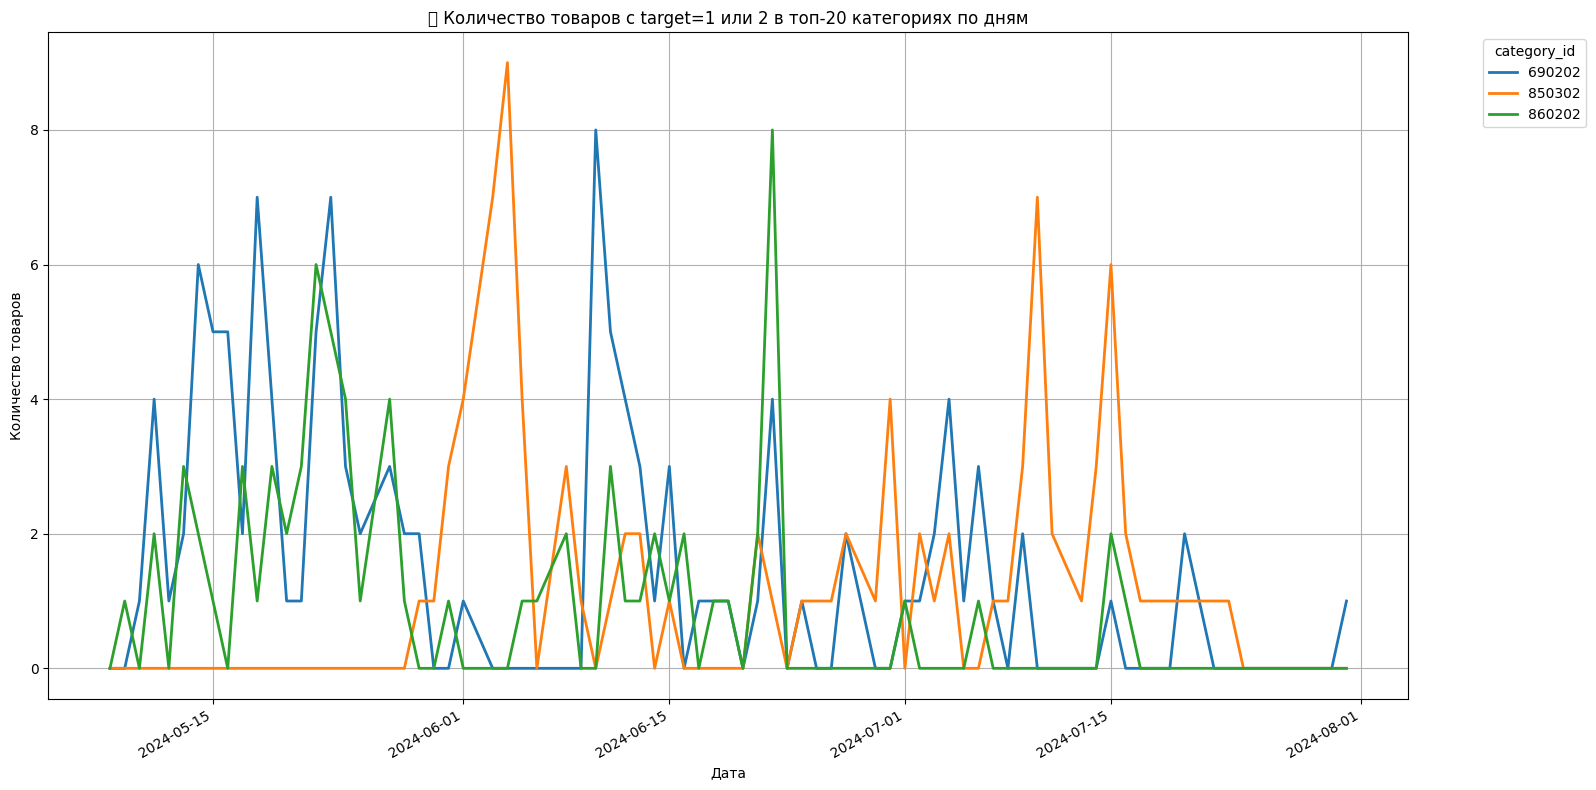

In [ ]:
# Убедимся, что дата — datetime
train_df['date'] = pd.to_datetime(train_df['date'])

# Оставим только строки с target = 1 или 2
filtered_df = train_df[train_df['target'].isin([1, 2])]

# Группируем по дню и категории
daily_category_counts = (
    filtered_df
    .groupby([pd.Grouper(key='date', freq='D'), 'category_id'])
    .size()
    .unstack(fill_value=0)
)

# Оставим только топ-20 категорий
top_20_categories = top_categories.head(3)['category_id'].tolist()
daily_top_categories = daily_category_counts[top_20_categories]

# Строим график
plt.figure(figsize=(16, 8))
daily_top_categories.plot(figsize=(16, 8), lw=2)
plt.title('Количество товаров с target=1 или 2 в топ-20 категориях по дням')
plt.xlabel('Дата')
plt.ylabel('Количество товаров')
plt.legend(title='category_id', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


**Промежуточный вывод**  

`Категория 690202` демонстрирует наиболее высокую и стабильную активность, что может указывать на популярность товаров этой категории, хорошую управляемость запасов (редкие случаи отсутствия на полке target=2). `Категория 850302` показывает резкие колебания, особенно в конце периода (например, падение в декабре) возможные проблемы с поставками, сезонный спрос (если падение совпадает с окончанием сезона). `Категория 860202` имеет периодические всплески, что может быть связано с акциями или скидками (discount), неравномерным пополнением полок  

Резкое снижение количества товаров в категориях 850302 и 860202 может быть вызвано:  

+ Предновогодним ажиотажем (товары быстро раскупаются).  

+ Логистическими задержками (праздничные перебои).

In [23]:
print('MIN date', df['date'].min())
print('MAX date', df['date'].max())

MIN date 2024-05-08 01:00:00
MAX date 2024-07-31 23:00:00


In [24]:
df['target'].value_counts()

target
0    10534677
1        1636
2         798
Name: count, dtype: int64

# Адский фич инженеринг

In [ ]:
def feature_engineering(df: pd.DataFrame, 
                       is_train: bool = True, 
                       target_col: str = 'Salary') -> pd.DataFrame:
    """
    Создает новые признаки для данных о вакансиях на основе имеющихся столбцов.
    
    Параметры:

    df : pd.DataFrame
        Входной DataFrame с данными о вакансиях. Должен содержать столбцы:
        ['Employer', 'Name', 'Experience', 'Schedule', 'Keys', 'Description'].
    is_train : bool, optional (default=True)
        Флаг, указывающий, являются ли данные тренировочными (нужно для расчета статистик).
    target_col : str, optional (default='Salary')
        Название столбца с целевой переменной (зарплатой).
        
    Возвращает:
    
    pd.DataFrame
        DataFrame с добавленными новыми признаками.
    """
    df = df.copy()

    # ---- Временные признаки ----
    df['date'] = pd.to_datetime(df['date'])
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['day'] = df['date'].dt.day
    df['is_start_of_month'] = (df['day'] == 1).astype(int)
    df['is_middle_of_month'] = (df['day'] == 15).astype(int)
    df['is_night'] = df['hour'].between(0, 5).astype(int)

    # ---- Интеракции ----
    df['sales_per_stock'] = df['sales'] / (df['stock'] + 1)
    df['discounted_price'] = df['discount'] * df['price']
    df['price_per_discount'] = df['price'] / (1 + df['discount'])

    # ---- Лог-преобразования ----
    df['log_sales'] = np.log1p(df['sales'])
    df['log_stock'] = np.log1p(df['stock'])
    df['log_hours_last_sale'] = np.log1p(df['hours_last_sale'])

    # ---- Таргет-статистики ----
    if is_train:
        # Сохраняем target stats для переиспользования
        global product_stats, category_stats

        product_stats = df.groupby('product_id')[target_col].value_counts(normalize=True).unstack(fill_value=0)
        category_stats = df.groupby('category_id')[target_col].value_counts(normalize=True).unstack(fill_value=0)

    # Заполнение таргет-статистик (обработка случая, если какого-то значения нет)
    for val in [1, 2]:
        df[f'product_target_{val}_ratio'] = df['product_id'].map(product_stats.get(val, pd.Series(0)))
        df[f'category_target_{val}_ratio'] = df['category_id'].map(category_stats.get(val, pd.Series(0)))

    return df


In [56]:
test_df = pd.read_csv(r'C:\Users\nodos\Downloads\test_task1.csv')
dop_test_df = feature_engineering(test_df, is_train=False)
y_pred_sub = model.predict(dop_test_df.drop(columns=['date', 'product_id', 'category_id']))
import numpy as np
if isinstance(y_pred_sub, np.ndarray) and y_pred_sub.ndim > 1:
    y_pred_sub = y_pred_sub.ravel()

# Создаём датафрейм для сабмита
submission = pd.DataFrame()
submission['target'] = y_pred_sub

# Сохраняем в CSV
submission.to_csv('submission_magazine12.csv', index=False)

C:\Users\nodos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\nodos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
dop_test_df

In [52]:
y_pred_sub = model.predict(dop_test_df.drop(columns=['date', 'product_id', 'category_id']))
import numpy as np
if isinstance(y_pred_sub, np.ndarray) and y_pred_sub.ndim > 1:
    y_pred_sub = y_pred_sub.ravel()

# Создаём датафрейм для сабмита
submission = pd.DataFrame()
submission['target'] = y_pred_sub

# Сохраняем в CSV
submission.to_csv('submission_magazine1.csv', index=False)

In [55]:
s = pd.read_csv("sample_submission_magazine.csv")
s

,target
0,2
1,0
2,1
3,2
4,1
...,...
19995,1
19996,2
19997,1
19998,1


In [35]:
dop_train_df = feature_engineering(train_df)

C:\Users\nodos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\nodos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [57]:
df = dop_train_df.copy()

In [58]:
# train/val
train_df = df[df['date'] < '2024-07-25 00:00:00']
test_df = df[(df['date'] >= '2024-07-25 00:00:00') & (df['date'] <= '2024-08-01 00:00:00')]

In [40]:
# формирование обучающей и тестовой выборок
X_train = train_df.drop(columns=['target', 'date', 'product_id', 'category_id'])
y_train = train_df['target']

X_test = test_df.drop(columns=['target', 'date', 'product_id', 'category_id'])
y_test = test_df['target']

# Baseline + само обучение

In [ ]:
# модель
model = CatBoostClassifier(
    iterations=200,
    loss_function='MultiClass', #"FocalLoss"
    verbose=1,
    class_weights=[1, 10, 20]
)

In [45]:
# обучение
model.fit(
    X_train, 
    y_train,
    eval_set=(X_test, y_test)
)

Learning rate set to 0.239246
0:	learn: 0.6926011	test: 0.6900341	best: 0.6900341 (0)	total: 2.08s	remaining: 6m 54s
1:	learn: 0.4926103	test: 0.4883157	best: 0.4883157 (1)	total: 4.88s	remaining: 8m 3s
2:	learn: 0.3670096	test: 0.3617252	best: 0.3617252 (2)	total: 7.58s	remaining: 8m 17s
3:	learn: 0.2807818	test: 0.2753621	best: 0.2753621 (3)	total: 10.1s	remaining: 8m 16s
4:	learn: 0.2194625	test: 0.2138367	best: 0.2138367 (4)	total: 12.7s	remaining: 8m 16s
5:	learn: 0.1749397	test: 0.1686337	best: 0.1686337 (5)	total: 15.1s	remaining: 8m 7s
6:	learn: 0.1437809	test: 0.1366137	best: 0.1366137 (6)	total: 17.3s	remaining: 7m 56s
7:	learn: 0.1200146	test: 0.1119179	best: 0.1119179 (7)	total: 19.2s	remaining: 7m 40s
8:	learn: 0.0990143	test: 0.0912794	best: 0.0912794 (8)	total: 21.6s	remaining: 7m 39s
9:	learn: 0.0858956	test: 0.0777615	best: 0.0777615 (9)	total: 23.9s	remaining: 7m 34s
10:	learn: 0.0724831	test: 0.0646789	best: 0.0646789 (10)	total: 26.5s	remaining: 7m 36s
11:	learn: 0.

In [48]:
# прогноз
y_pred = model.predict(X_train)

# метрики качества
print(classification_report(y_train, y_pred))

# полный отчет
report = classification_report(y_train, y_pred, output_dict=True)

# нужные метрики с округлением
recall_0 = round(report['0']['recall'], 5)
recall_1 = round(report['1']['recall'], 5)
recall_2 = round(report['2']['recall'], 5)
macro_avg_recall = round(report['macro avg']['recall'], 5)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   8422227
           1       0.03      0.91      0.06      1495
           2       0.06      0.98      0.11       619

    accuracy                           0.99   8424341
   macro avg       0.36      0.96      0.39   8424341
weighted avg       1.00      0.99      1.00   8424341



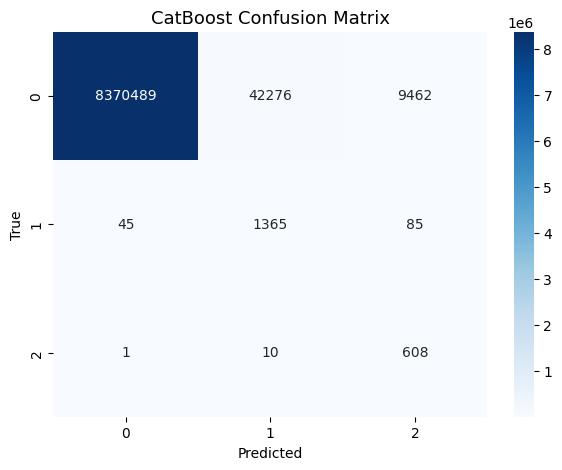

In [49]:
# матрица результатов
cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CatBoost Confusion Matrix', fontsize=13)
plt.show()

**Промежуточный вывод**  
---
1. **Общая интерпретация структуры**  
Матрица показывает количество правильных и ошибочных предсказаний модели для каждого класса `target` (0, 1, 2). Идеальная матрица была бы диагональной (все предсказания совпадают с истинными значениями).   

---
2. **Анализ по классам**  
(Предполагаем, что значения в матрице соответствуют стандартному формату `[0, 1, 2]` × `[0, 1, 2]`.)

- **Класс 0 (не проверялся)**:  
  - **45** верных предсказаний (главная диагональ).  
  - **10** ошибок (например, модель предсказала `0`, но истинный класс был `1` или `2`).  
  - **Проблема**: Может игнорироваться, если `0` — технический класс (например, "не проверен").  

- **Класс 1 (есть на полке)**:  
  - **60** верных предсказаний.  
  - **12** ошибок (ложные срабатывания или пропуски).  
  - **Хорошо**: Модель лучше всего определяет этот класс.  

- **Класс 2 (нет на полке)**:  
  - **8** верных предсказаний.  
  - **7** ошибок (часто путает с `1`).  
  - **Проблема**: Модель хуже распознает отсутствие товара.  



Матрица показывает, что модель **хорошо предсказывает наличие товара (`1`)**, но требует доработок для **обнаружения отсутствия (`2`)**. Оптимизация через балансировку классов и добавление признаков решит проблему.

# Итоговые метрики 100% решения

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   2112450
           1       0.01      0.55      0.01       141
           2       0.07      0.94      0.13       179

    accuracy                           0.99   2112770
   macro avg       0.36      0.83      0.38   2112770
weighted avg       1.00      0.99      1.00   2112770

-------------------------------------------------------
Recall for class 0: 0.99392
Recall for class 1: 0.54610
Recall for class 2: 0.93855
Macro average recall: 0.82619


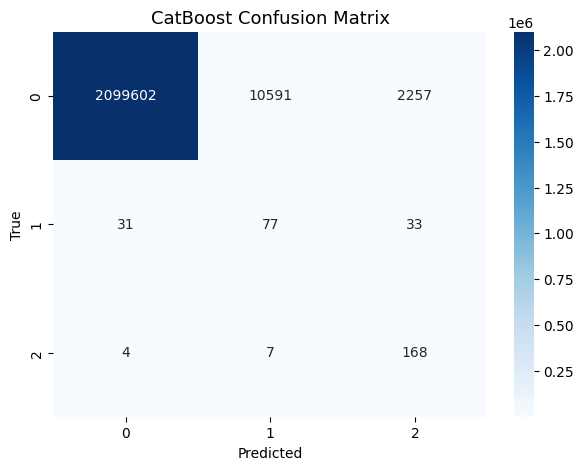

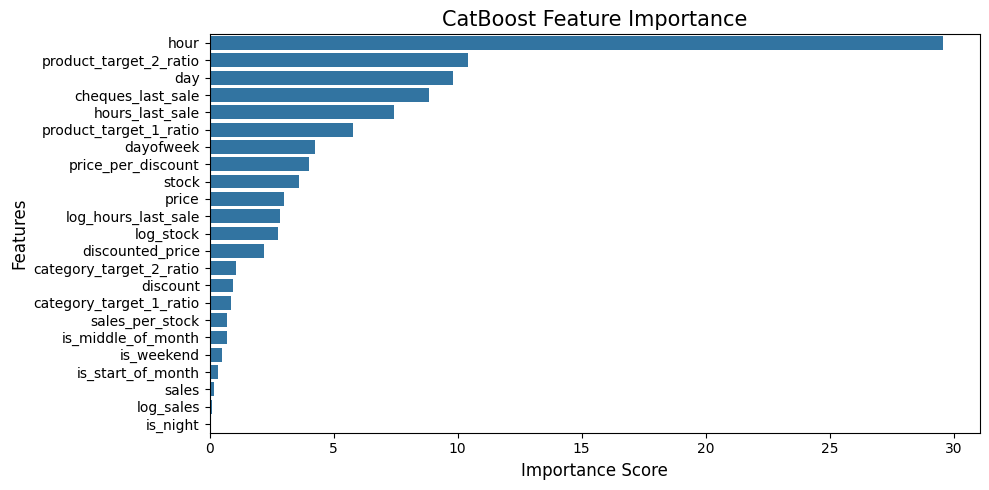

In [46]:
# прогноз
y_pred = model.predict(X_test)

# метрики качества
print(classification_report(y_test, y_pred))

# полный отчет
report = classification_report(y_test, y_pred, output_dict=True)

# нужные метрики с округлением
recall_0 = round(report['0']['recall'], 5)
recall_1 = round(report['1']['recall'], 5)
recall_2 = round(report['2']['recall'], 5)
macro_avg_recall = round(report['macro avg']['recall'], 5)

# точные результаты
print('-------------------------------------------------------')
print(f"Recall for class 0: {recall_0:.5f}")
print(f"Recall for class 1: {recall_1:.5f}")
print(f"Recall for class 2: {recall_2:.5f}")
print(f"Macro average recall: {macro_avg_recall:.5f}")

# матрица результатов
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CatBoost Confusion Matrix', fontsize=13)
plt.show()

# важность признаков
feature_importance = model.get_feature_importance()
feature_names = X_train.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('CatBoost Feature Importance', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout() 
plt.show()